In [1]:
import numpy as np
import matplotlib as mp

number_teams = 5322
highestprofit = 125850
medianprofit = 89580

# generate 10000 fake team profits
#range from 0 to 125850, median around 89500
# range of our profit extra will be between 0.5-0.15
#clacualte our extra profit, using 0.15, why? becasue 0.15, is in the middle of or reange of the alpha 0.05-0,15


class montecarlo():

    def __init__(self, medianprofit,number_teams):
        self.medianprofit = medianprofit
        self.number_teams = number_teams
        self.expected_median = []

    def monte(self):
        for i in range(10000):
            alpha = np.random.uniform(0.05,0.25)
            shade = np.random.uniform(0.3,0.9) #We use shade becasue we can expect a rational team to bid below the median by abit]
            generated_median = (alpha * shade * self.medianprofit) #this is the median bid price each time
            (self.expected_median).append(generated_median)


own_extra_profit = 0.15 * 90535 ###IMOPRTANT : 0.15 can be changed, becasue were assuming we will only get 15% more profit if we get extra quotes
mc = montecarlo(89580,5322)
mc.monte()


"""Let me explain this part here,
These are the bids we a re consdiering making, were chekcing through every single bid to find which one gives us the best expected value . Maximum simulated bid median from 
part 1 was around 20,000 so thats the upper limit that we should be checking. anything over that is a 100% bid win, but to us were overpaying.
and we start at 0 becasue its the most optimal bid""" #the 100 can be tightened to groups of 10 and 50 etc for more precisio

candidate_bids = np.arange(0 , 20000, 1) #the last number can be changed, lower numebr more precision
expected_value = []

simulated_median = np.array(mc.expected_median) # created an array of the expecrted median list from the MC simulation
    
for i in candidate_bids:
    p_clear = np.mean(simulated_median < i ) #the probability of clearing the median bid is the mean of the simulated medians that are smaller 
    gain = own_extra_profit - i
    ev = p_clear * gain
    expected_value.append(ev)


best_value_placement = np.argmax(expected_value)
best_bid = candidate_bids[best_value_placement]
print(best_bid) #maximises expected value

#proportion below the best bid
belowbestbid = np.mean(simulated_median < best_bid)
print(belowbestbid)
    
        
    





#evaluation

7596
0.5237


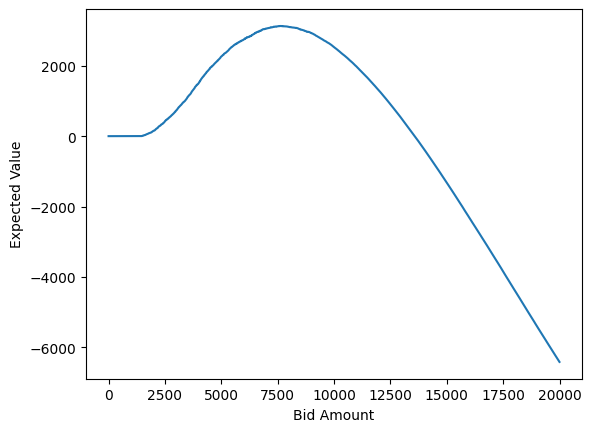

In [2]:
import matplotlib.pyplot as plt
plt.plot(candidate_bids, expected_value)
plt.xlabel('Bid Amount')
plt.ylabel('Expected Value')
plt.show()

In [3]:
"""
okay heres my method
the median profit i got from round one was 89580, the total teams i took into account was 5322 aroud there, i disquialified the teams that were in the negative or tied at 0 xirecs

alpha : this is the fraction of the profit that the extra market acces is worth, i gave it a range of 0.05 to 0.25

shade : this is t he fractio of the profit that the extra market access is worth, i gave it a range of 0.3 to 0.9, the caveat is that we dont know how aggressive each team is. 

The theory i read up on was the auction theory , rational bidders bid below the true valid, so we say about 30-90% of the value

So an E(V) of the median a team MIGHT bid would be :  alpha * shade * medianbid of about 89580

Next part, I ran a monte carlo, to simulate 10000 scenarios with the above fraction values for alpha and shade, giving us a proper distribution of waht the median bid might be

The second part, we test every possible bid that is in the array , from 0 to 20,000 (highest value possible)
We loop it through the list of possible bids, and see if this bid beat the simulated medians generated. Multiply that by how much profit we would keep after paying for the bid
Then we get a bid with the highest exepcted value as our optimal bid, which was around 7800 XIRECs
"""

'\nokay heres my method\nthe median profit i got from round one was 89580, the total teams i took into account was 5322 aroud there, i disquialified the teams that were in the negative or tied at 0 xirecs\n\nalpha : this is the fraction of the profit that the extra market acces is worth, i gave it a range of 0.05 to 0.25\n\nshade : this is t he fractio of the profit that the extra market access is worth, i gave it a range of 0.3 to 0.9, the caveat is that we dont know how aggressive each team is. \n\nThe theory i read up on was the auction theory , rational bidders bid below the true valid, so we say about 30-90% of the value\n\nSo an E(V) of the median a team MIGHT bid would be :  alpha * shade * medianbid of about 89580\n\nNext part, I ran a monte carlo, to simulate 10000 scenarios with the above fraction values for alpha and shade, giving us a proper distribution of waht the median bid might be\n\nThe second part, we test every possible bid that is in the array , from 0 to 20,000 (h